# SentiScope: Customer Review Sentiment Analysis

**Member:** Bosilu  
**Models:** Multinomial Naive Bayes and GRU  
**Branch:** feature/bosilu-model

In [5]:
!pip install -q scikit-learn pandas numpy nltk textblob tensorflow matplotlib seaborn imbalanced-learn wordcloud
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
import pandas as pd

df = pd.read_csv('/content/amazon.csv')

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (1465, 16)


In [7]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [8]:
df.columns.tolist()

['product_id',
 'product_name',
 'category',
 'discounted_price',
 'actual_price',
 'discount_percentage',
 'rating',
 'rating_count',
 'about_product',
 'user_id',
 'user_name',
 'review_id',
 'review_title',
 'review_content',
 'img_link',
 'product_link']

In [9]:
df[['review_content', 'review_title', 'rating']].head(10)

,review_content,review_title,rating
0,Looks durable Charging is fine tooNo complains...,"Satisfied,Charging is really fast,Value for mo...",4.2
1,I ordered this cable to connect my phone to An...,"A Good Braided Cable for Your Type C Device,Go...",4.0
2,"Not quite durable and sturdy,https://m.media-a...","Good speed for earlier versions,Good Product,W...",3.9
3,"Good product,long wire,Charges good,Nice,I bou...","Good product,Good one,Nice,Really nice product...",4.2
4,"Bought this instead of original apple, does th...","As good as original,Decent,Good one for second...",4.2
5,"It's a good product.,Like,Very good item stron...","It's pretty good,Average quality,very good and...",3.9
6,Build quality is good and it is comes with 2 y...,"Long durable.,good,Does not charge Lenovo m8 t...",4.1
7,Worth for money - suitable for Android auto......,"Worth for money - suitable for Android auto,Go...",4.3
8,I use this to connect an old PC to internet. I...,Works on linux for me. Get the model with ante...,4.2
9,I ordered this cable to connect my phone to An...,"A Good Braided Cable for Your Type C Device,Go...",4.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [11]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [12]:
df['rating'].value_counts().sort_index()

,count
rating,
2,1
2.3,1
2.6,1
2.8,2
2.9,1
3,1
3.0,3
3.1,4
3.2,2


In [13]:
df[['review_content', 'review_title', 'rating']].head(10)

,review_content,review_title,rating
0,Looks durable Charging is fine tooNo complains...,"Satisfied,Charging is really fast,Value for mo...",4.2
1,I ordered this cable to connect my phone to An...,"A Good Braided Cable for Your Type C Device,Go...",4.0
2,"Not quite durable and sturdy,https://m.media-a...","Good speed for earlier versions,Good Product,W...",3.9
3,"Good product,long wire,Charges good,Nice,I bou...","Good product,Good one,Nice,Really nice product...",4.2
4,"Bought this instead of original apple, does th...","As good as original,Decent,Good one for second...",4.2
5,"It's a good product.,Like,Very good item stron...","It's pretty good,Average quality,very good and...",3.9
6,Build quality is good and it is comes with 2 y...,"Long durable.,good,Does not charge Lenovo m8 t...",4.1
7,Worth for money - suitable for Android auto......,"Worth for money - suitable for Android auto,Go...",4.3
8,I use this to connect an old PC to internet. I...,Works on linux for me. Get the model with ante...,4.2
9,I ordered this cable to connect my phone to An...,"A Good Braided Cable for Your Type C Device,Go...",4.0


In [14]:
df['rating'].head(10)

,rating
0,4.2
1,4.0
2,3.9
3,4.2
4,4.2
5,3.9
6,4.1
7,4.3
8,4.2
9,4.0


In [15]:
print("Rating data type:", df['rating'].dtype)

Rating data type: object


In [16]:
df['rating'].value_counts().sort_index()

,count
rating,
2,1
2.3,1
2.6,1
2.8,2
2.9,1
3,1
3.0,3
3.1,4
3.2,2


In [17]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [18]:
print("Missing ratings:", df['rating'].isnull().sum())

Missing ratings: 1


In [19]:
df[df['rating'].isnull()][
    ['product_name', 'review_title', 'review_content', 'rating']
]

,product_name,review_title,review_content,rating
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",NaN


In [20]:
df = df.dropna(subset=['rating']).copy()

In [21]:
df.reset_index(drop=True, inplace=True)

In [22]:
print("Missing ratings:", df['rating'].isnull().sum())
print("Dataset shape after removal:", df.shape)

Missing ratings: 0
Dataset shape after removal: (1464, 16)


In [23]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

In [24]:
df[['rating', 'sentiment']].head(10)

,rating,sentiment
0,4.2,Positive
1,4.0,Positive
2,3.9,Positive
3,4.2,Positive
4,4.2,Positive
5,3.9,Positive
6,4.1,Positive
7,4.3,Positive
8,4.2,Positive
9,4.0,Positive


In [25]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,1459
Neutral,4
Negative,1


In [26]:
df['sentiment'].value_counts(normalize=True) * 100

,proportion
sentiment,
Positive,99.658470
Neutral,0.273224
Negative,0.068306


### Missing-rating handling

After converting the rating column to numeric format, one record contained a
missing or invalid rating. Because sentiment labels are generated directly from
ratings, this record was removed rather than assigning an artificial rating or
sentiment. The cleaned dataset contains 1,464 records.

In [27]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts

,count
sentiment,
Positive,1459
Neutral,4
Negative,1


In [28]:
sentiment_percentages = df['sentiment'].value_counts(normalize=True) * 100
sentiment_percentages.round(2)

,proportion
sentiment,
Positive,99.66
Neutral,0.27
Negative,0.07


In [29]:
print(df['sentiment'].unique())
print("Number of sentiment classes:", df['sentiment'].nunique())

['Positive' 'Neutral' 'Negative']
Number of sentiment classes: 3


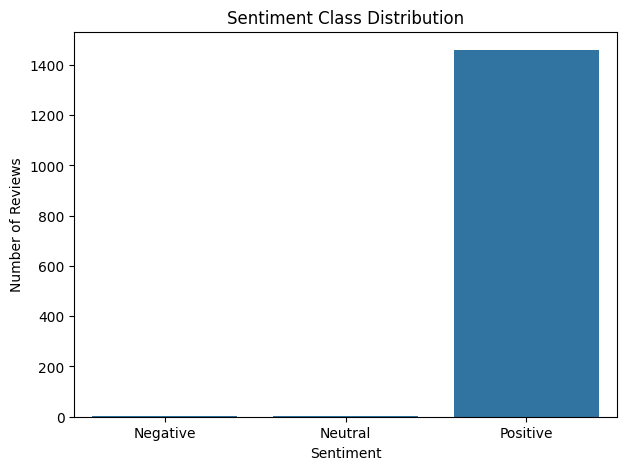

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='sentiment',
    order=['Negative', 'Neutral', 'Positive']
)

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the dataset
df = pd.read_csv('/content/amazon.csv')

# Convert ratings to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Remove the row with the missing/invalid rating
df = df.dropna(subset=['rating']).copy()
df.reset_index(drop=True, inplace=True)

# Recreate sentiment labels
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print("Dataset restored successfully")
print("Dataset shape:", df.shape)
print(df['sentiment'].value_counts())

Dataset restored successfully
Dataset shape: (1464, 17)
sentiment
Positive    1459
Neutral        4
Negative       1
Name: count, dtype: int64


In [32]:
sentiment_counts = df['sentiment'].value_counts()

print("Sentiment counts:")
print(sentiment_counts)

Sentiment counts:
sentiment
Positive    1459
Neutral        4
Negative       1
Name: count, dtype: int64


In [33]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Positive    1459
Neutral        4
Negative       1
Name: count, dtype: int64


In [34]:
sentiment_percentages = (
    df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentages)

sentiment
Positive    99.66
Neutral      0.27
Negative     0.07
Name: proportion, dtype: float64


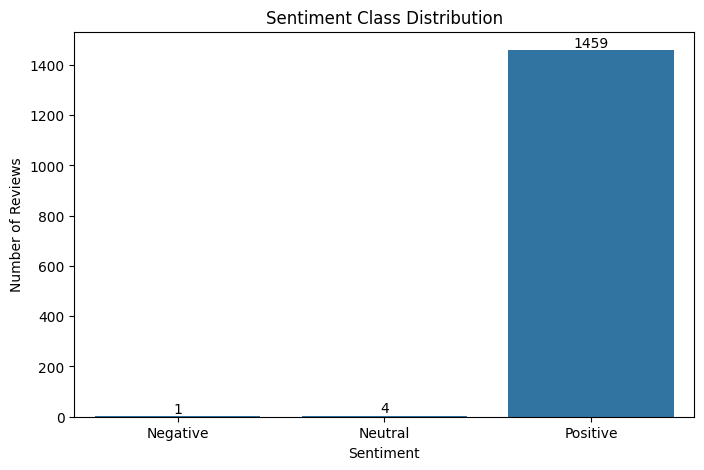

In [35]:
order = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='sentiment',
    order=order
)

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [36]:
df['rating'].describe()

,rating
count,1464.000000
mean,4.096585
std,0.291674
min,2.000000
25%,4.000000
50%,4.100000
75%,4.300000
max,5.000000


In [37]:
df['rating'].value_counts().sort_index()

,count
rating,
2.0,1
2.3,1
2.6,1
2.8,2
2.9,1
3.0,4
3.1,4
3.2,2
3.3,16


In [38]:
df[['rating', 'review_title', 'review_content']].sort_values(
    by='rating'
).head(10)

,rating,review_title,review_content
1308,2.0,"Bad quality,Amazing product..",The heating capacity is zero .Moreover i have ...
1243,2.3,"Nice product i recommend to buy,Do not buy!! D...","I liked that it is so convenient to carry,Wast..."
1355,2.6,"It is broken,Could have been a bit better,The ...",It is broken and it is not useful. Please chan...
545,2.8,"Very Good prodat,Battery life is 0 day,Good,Wh...","Good Prodat,Battery life is so bad.,Nice produ..."
1285,2.8,"Portable but not much powerful,not so good. po...","Not sufficient power,the product is more like ..."
1448,2.9,"Stop working after few days,Ok. Changing every...","Stop working after few days,Ok,It doesn't fit ..."
282,3.0,The cable works but is not 65W as advertised,I have a pd supported car charger and I bought...
550,3.0,"Its is good but battery life is very poor,Hear...","Its is value for money,,Good product,Good, lik..."
263,3.0,"Not good,No voice recognition, No pointer ray ...",The mouse feature of the remote is not working...
1314,3.0,"Not worth the hype,Gud,Really useful 😃,Product...",Hi viewers so I bought this product after watc...


## Dataset Suitability Issue

Using the proposed rating thresholds produced an extremely imbalanced dataset:

- Negative: 1 review
- Neutral: 4 reviews
- Positive: 1,459 reviews

This distribution is unsuitable for reliable three-class sentiment classification.
The minority classes contain too few real examples for meaningful model training,
evaluation, stratified splitting, class weighting, or oversampling.

In [39]:
import pandas as pd

df = pd.read_csv('/content/amazon.csv')

df['rating'] = pd.to_numeric(
    df['rating'],
    errors='coerce'
)

df = df.dropna(subset=['rating']).copy()
df.reset_index(drop=True, inplace=True)

print("Dataset restored:", df.shape)

Dataset restored: (1464, 16)


In [40]:
rating_distribution = (
    df['rating']
    .value_counts()
    .sort_index()
)

print("Rating distribution:")
print(rating_distribution)

Rating distribution:
rating
2.0      1
2.3      1
2.6      1
2.8      2
2.9      1
3.0      4
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4.0    181
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      3
Name: count, dtype: int64


In [41]:
import pandas as pd

# Reload dataset
df = pd.read_csv('/content/amazon.csv')

# Convert rating column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Remove the one invalid/missing rating
df = df.dropna(subset=['rating']).copy()
df.reset_index(drop=True, inplace=True)

# Recreate sentiment labels
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print("Dataset shape:", df.shape)

print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nSentiment percentages:")
print(
    df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dataset shape: (1464, 17)

Rating distribution:
rating
2.0      1
2.3      1
2.6      1
2.8      2
2.9      1
3.0      4
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4.0    181
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      3
Name: count, dtype: int64

Sentiment distribution:
sentiment
Positive    1459
Neutral        4
Negative       1
Name: count, dtype: int64

Sentiment percentages:
sentiment
Positive    99.66
Neutral      0.27
Negative     0.07
Name: proportion, dtype: float64


## Dataset Suitability Finding

After applying the approved sentiment-labeling rule, the dataset produced:

- Negative: 1 review
- Neutral: 4 reviews
- Positive: 1,459 reviews

This distribution is extremely imbalanced and is unsuitable for reliable
three-class model training and evaluation. A stratified train-test split may
also fail because the Negative class contains only one example.

The group must therefore review the dataset choice or obtain lecturer approval
for a revised labeling strategy before continuing with model development.